<a href="https://colab.research.google.com/github/andrew-janes-07/cartpendulums-lqr-control/blob/main/notebooks/02_double_pendulum_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Double Pendulum on a Cart — LQR Stabilization

The double pendulum is the canonical example of a chaotic system. Unlike the single pendulum,
the coupled nonlinear dynamics of two links produce trajectories that are exponentially sensitive
to initial conditions — a qualitative change that no amount of numerical precision can overcome.
Adding a cart introduces a third degree of freedom and the control objective: stabilize all three
coordinates at the fully upright equilibrium $\mathbf{y}^* = [0,\ \pi,\ \pi,\ 0,\ 0,\ 0]^\top$
using only a horizontal force on the cart.

The same `PendulumSystem` architecture from the single pendulum notebook handles $n=2$ without
modification. The dynamics are formed based on the number of links and if the cart is present. This notebook focuses on the differences from the single pendulum case. The dynamics are significantly more nonlinear adding velocity terms to the system and they exhibit chaotic behavior leading to greater difficulty controlling the system.

# Demonstrating LQR control with a deadband for a double pendulum on a cart as a baseline.

As the double pendulum model is a stepping stone from the basic cart-pendulum to the cart-triple pendulum, I will only explore a few cases here that help set up the triple case.

In [2]:
# Setup
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    if not os.path.exists("cartpendulums-lqr-control"):
        !git clone https://github.com/andrew-janes-07/cartpendulums-lqr-control.git
    %cd cartpendulums-lqr-control
    #!pip install -q -r requirements.txt
else:
    import sys
    sys.path.append("..")

Cloning into 'cartpendulums-lqr-control'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 63 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 997.75 KiB | 5.64 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/cartpendulums-lqr-control


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from src.config import PendulumConfig
from src.system import PendulumSystem
from src.controllers import LQRController, DeadbandActuator

In [4]:
def plot_pendulum_states(sim, n: int, is_cart: bool, title_prefix: str = "", figsize=None, fig=None, axes=None, label=None, color=None):
    """
    Plot state trajectories for an n-link pendulum, with or without a cart.

    State vector layout:
        Cart:        [x, θ₁..θₙ, ẋ, ω₁..ωₙ]
        Fixed-pivot: [θ₁..θₙ, ω₁..ωₙ]

    Parameters
    ----------
    sim        : OdeResult from solve_ivp
    n          : number of pendulum links
    is_cart    : whether system has a cart
    title_prefix: optional string prepended to each subplot title
    figsize    : override default figure size
    """
    n_coords = n + int(is_cart)  # total generalised coordinates

    if figsize is None:
        figsize = (12, 6 * n_coords)

    if fig is None or axes is None:
        fig, axes = plt.subplots(n_coords, 2, figsize=figsize)
        if n_coords == 1:
            axes = axes[np.newaxis, :]
    # --- build label lists in state vector order ---
    if is_cart:
        coord_labels  = [r"$x_c$ (m)"]        + [rf"$\theta_{i+1}$ (rad)" for i in range(n)]
        vel_labels    = [r"$\dot{x}_c$ (m/s)"] + [rf"$\dot{{\theta}}_{i+1}$ (rad/s)" for i in range(n)]
        coord_titles  = [r"$x_c$"]             + [rf"$\theta_{i+1}$" for i in range(n)]
        vel_titles    = [r"$\dot{x}_c$"]       + [rf"$\dot{{\theta}}_{i+1}$" for i in range(n)]
    else:
        coord_labels  = [rf"$\theta_{i+1}$ (rad)"     for i in range(n)]
        vel_labels    = [rf"$\dot{{\theta}}_{i+1}$ (rad/s)" for i in range(n)]
        coord_titles  = [rf"$\theta_{i+1}$"            for i in range(n)]
        vel_titles    = [rf"$\dot{{\theta}}_{i+1}$"    for i in range(n)]

    prefix = f"{title_prefix} " if title_prefix else ""

    for i in range(n_coords):
        # positions/angles in first half of state vector, velocities in second half
        axes[i, 0].plot(sim.t, sim.y[i], label=label, color=color, linewidth=.5)
        axes[i, 1].plot(sim.t, sim.y[i + n_coords], label=label, color=color, linewidth=.5)

        axes[i, 0].set_xlabel("time (s)")
        axes[i, 1].set_xlabel("time (s)")
        axes[i, 0].set_ylabel(coord_labels[i])
        axes[i, 1].set_ylabel(vel_labels[i])
        axes[i, 0].set_title(f"{prefix}{coord_titles[i]} vs t")
        axes[i, 1].set_title(f"{prefix}{vel_titles[i]} vs t")

    #fig.tight_layout()
    return fig, axes

## Classic double Pendulum Behavior

### Small angle initial conditions to verify approximate linear system behavior.

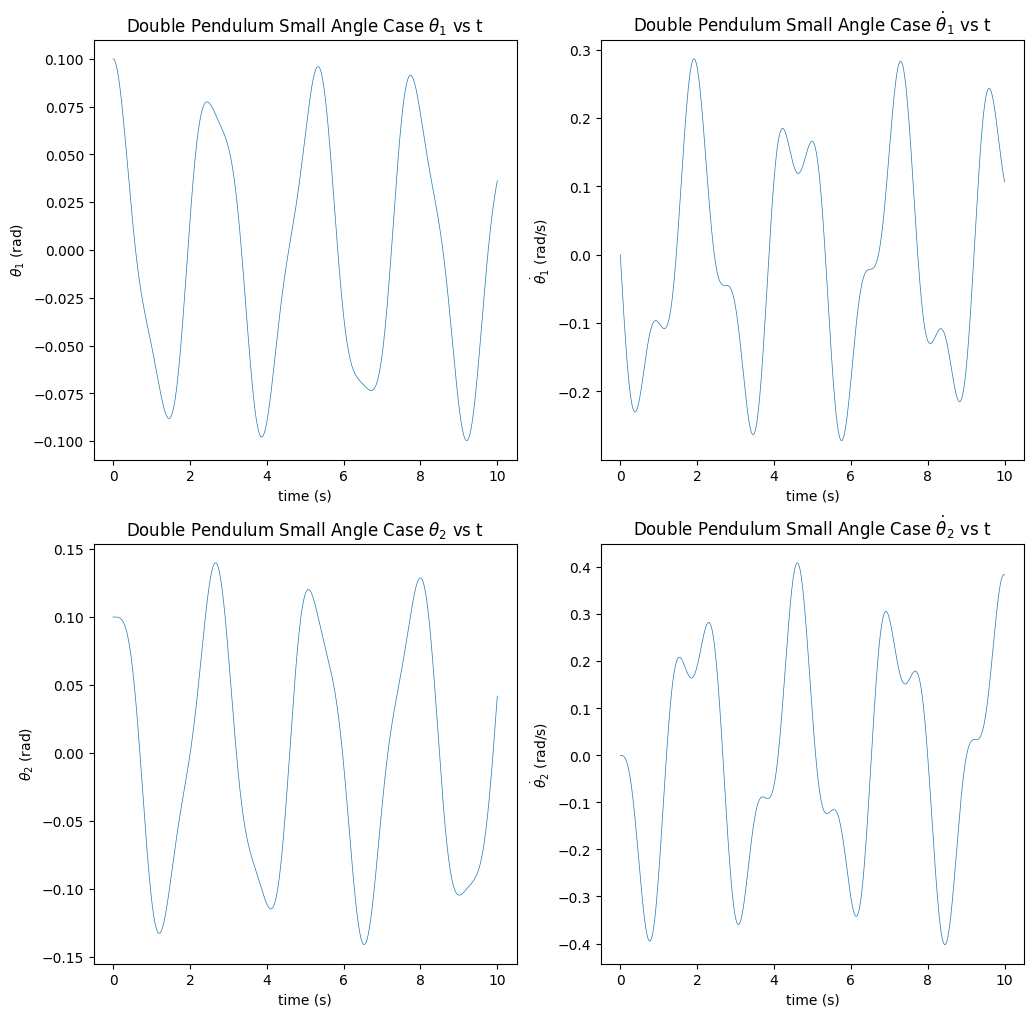

In [5]:
# Initialize Pendulum Configs class
n = 2
is_cart=False
params_double = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets all pendulum masses to 1kg and all lengths to 1m.
small_angle_ICs_double = params_double.small_angle_ICs() # Sets initial conditions to theta = .01 and theta_dot = 0
sys_double_0 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_double, ICs=small_angle_ICs_double) # Initializes the PendulumSystem class for the double pendulum with small angle initial conditions and default params
sim_double_0 = sys_double_0.simulate() # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_double_0, n=n, is_cart=is_cart, title_prefix="Double Pendulum Small Angle Case")
plt.show()


Both angles oscillate with uneven frequencies as expected. The system is essentially linear at these initial conditions. To view the state space plots, go to the tests.ipynb notebook in the `cartpendulums-lqr-control` repository. They show the expected lissajous curves for small angle initial conditions.

### Demonstrating chaos in the double pendulum.

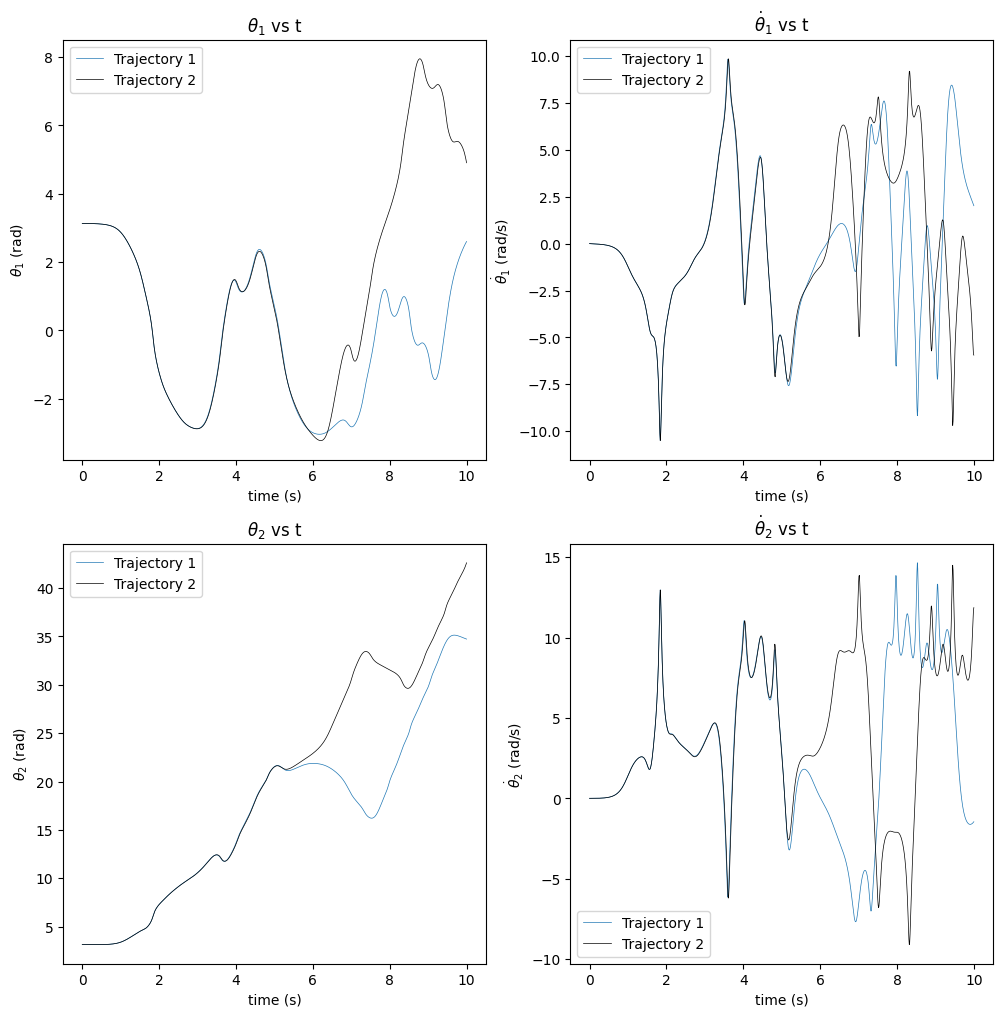

In [6]:
# Initialize Pendulum Configs class
n = 2
is_cart=False
eps = .0001
disturbance = np.array([eps, eps, 0, 0]) # Small perturbation from the initial conditions to see chaotic behavior of two trajectories
params_double = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets all pendulum masses to 1kg and all lengths to 1m.
near_vertical_ICs_double = params_double.chaotic_ICs() # Sets initial conditions to theta = pi - eps (small parameter = .1 default) and theta_dot = 0
sys_double_chaotic_1 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_double, ICs=near_vertical_ICs_double) # Initializes the PendulumSystem class for the double pendulum with small angle initial conditions and default params
sys_double_chaotic_2 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_double, ICs=near_vertical_ICs_double+disturbance)
sim_double_chaotic_1 = sys_double_chaotic_1.simulate() # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None
sim_double_chaotic_2 = sys_double_chaotic_2.simulate()


# Plot coord vs time and velocity vs time
fig, axes = plot_pendulum_states(sim_double_chaotic_1, n=n, is_cart=is_cart, label="Trajectory 1")
plot_pendulum_states(sim_double_chaotic_2, n=n, is_cart=is_cart,
                     fig=fig, axes=axes, label="Trajectory 2", color='k')

for ax in axes.flat:
    ax.legend()

plt.show()

1.4078448841106597


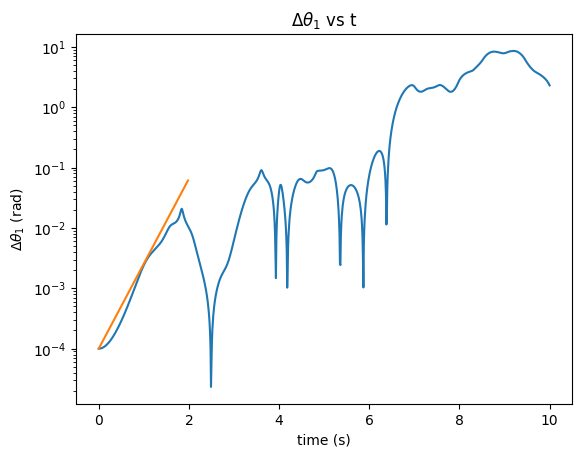

In [7]:
delta_theta_1 = np.abs(sim_double_chaotic_1.y[0]-sim_double_chaotic_2.y[0])
theta_1_lyapunov_base_10 =  np.log10(delta_theta_1[99])-np.log10(delta_theta_1[0])/(sim_double_chaotic_1.t[99]-sim_double_chaotic_1.t[0])
print(theta_1_lyapunov_base_10)

plt.semilogy(sim_double_chaotic_1.t, delta_theta_1)
plt.semilogy(sim_double_chaotic_1.t[0:199], delta_theta_1[0]*10**(theta_1_lyapunov_base_10*sim_double_chaotic_1.t[0:199]))
plt.xlabel('time (s)')
plt.ylabel(r'$\Delta \theta_1$ (rad)')
plt.title(r'$\Delta \theta_1$ vs t')
plt.show()

1.3357892257534574


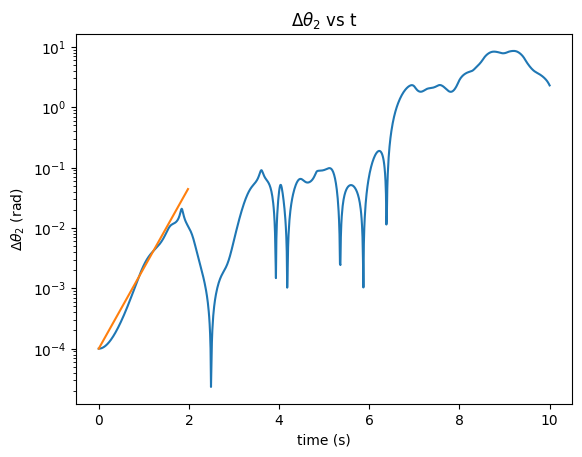

In [8]:
delta_theta_2= np.abs(sim_double_chaotic_1.y[1]-sim_double_chaotic_2.y[1])
theta_2_lyapunov_base_10 =  np.log10(delta_theta_2[99])-np.log10(delta_theta_2[0])/(sim_double_chaotic_1.t[99]-sim_double_chaotic_1.t[0])
print(theta_2_lyapunov_base_10)

plt.semilogy(sim_double_chaotic_1.t, delta_theta_1)
plt.semilogy(sim_double_chaotic_1.t[0:199], delta_theta_2[0]*10**(theta_2_lyapunov_base_10*sim_double_chaotic_1.t[0:199]))
plt.xlabel('time (s)')
plt.ylabel(r'$\Delta \theta_2$ (rad)')
plt.title(r'$\Delta \theta_2$ vs t')
plt.show()

Plotting the absolute value of the difference between $\theta_1$ and $\theta_2$ for each trajectory on a log plot and then calculating the base 10 lyapunov exponent over the first second of each trajectory gives a lyapunov expression of $$|\Delta \theta_1| \sim 10^{1.41t}$$ and $$|\Delta \theta_2| \sim 10^{1.34t}$$ Both of these expressions approximate the growth of the separation extremely well for the first few seconds of motion until the trajectories reapproach each other due to the way the angles will loop back and come close together.

This is the expected behavior of a chaotic system.

## Behavior of a double Pendulum with a Cart

Near vertical initial conditions for a double pendulum on a cart. Showing oscillation of both coordinates $x_c$ and $\theta$. This is the system we desire control over. There are theoretically 3 different unstable equilibriums for the double pendulum corresponding to the cases where at least one pendulum is vertical. For the double pendulum, I will focus on the fully vertical case only.

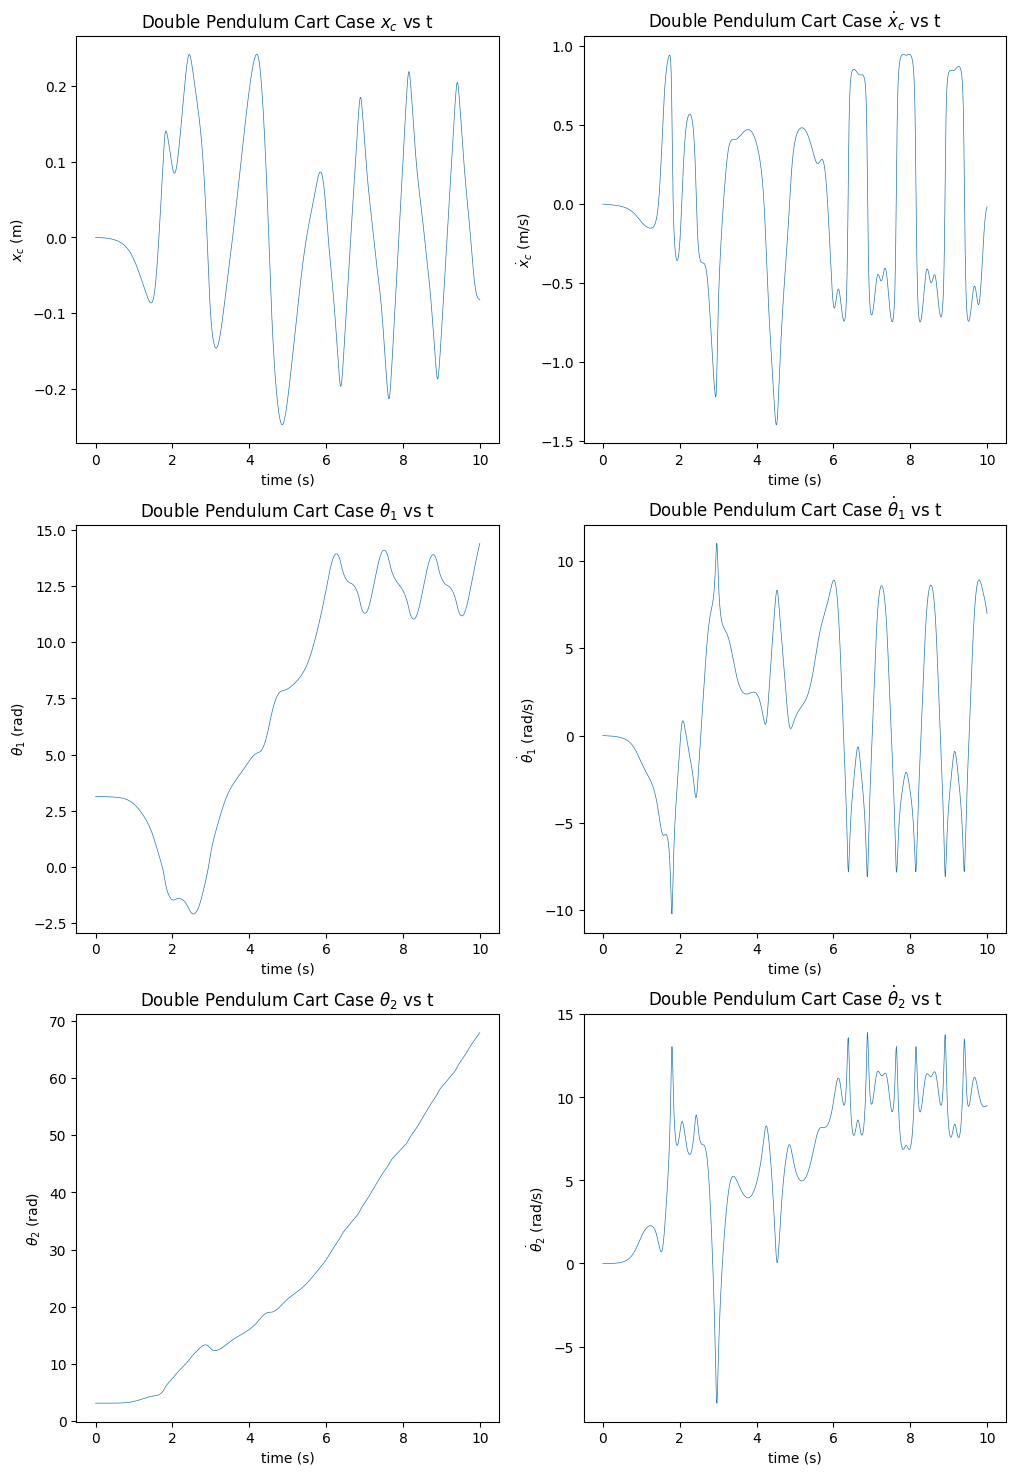

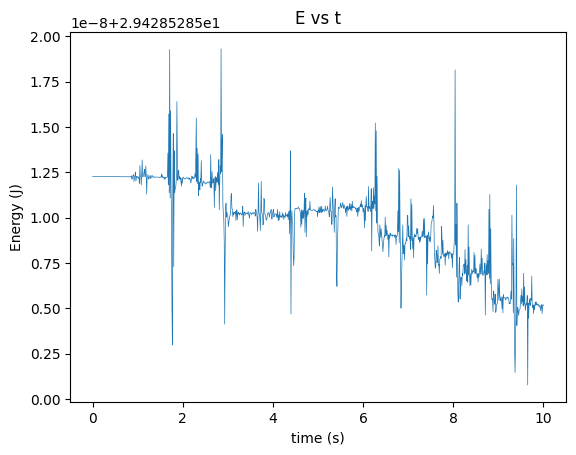

In [9]:
# Initialize Pendulum Configs class
n = 2
is_cart=True
params_double_cart = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg and all pendulum masses to 1kg and all lengths to 1m.
near_vertical_ICs_double_cart = params_double_cart.chaotic_ICs() # Sets initial conditions to theta = pi - eps (small parameter = .1 default) and theta_dot = 0
sys_double_cart = PendulumSystem(n=n, is_cart=is_cart, cfg=params_double_cart, ICs=near_vertical_ICs_double_cart) # Initializes the PendulumSystem class for the double pendulum with small angle initial conditions and default params
sim_double_cart = sys_double_cart.simulate() # Uses defaults: solver='DOP853', t_span=(0,10), dt=.01, controller=None
ke_cart, pe_cart, energy_double_cart = sys_double_cart.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_double_cart, n=n, is_cart=is_cart, title_prefix="Double Pendulum Cart Case")
plt.show()


# Plot energy vs time
plt.plot(sim_double_cart.t, energy_double_cart, linewidth=.5)
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('E vs t')
plt.show()

This case exhibits very similar behavior to the cartless double pendulum. This is the most computation intensive simulation without control for the double pendulum. Energy is still conserved at the `1e-9` level (compared to the initial magnitude of $29\mathrm{J}$) which is acceptable considering the nonlinear nature of this problem.

## LQR control of the double pendulum

Starting with pure LQR control using finite differences for the linearization.

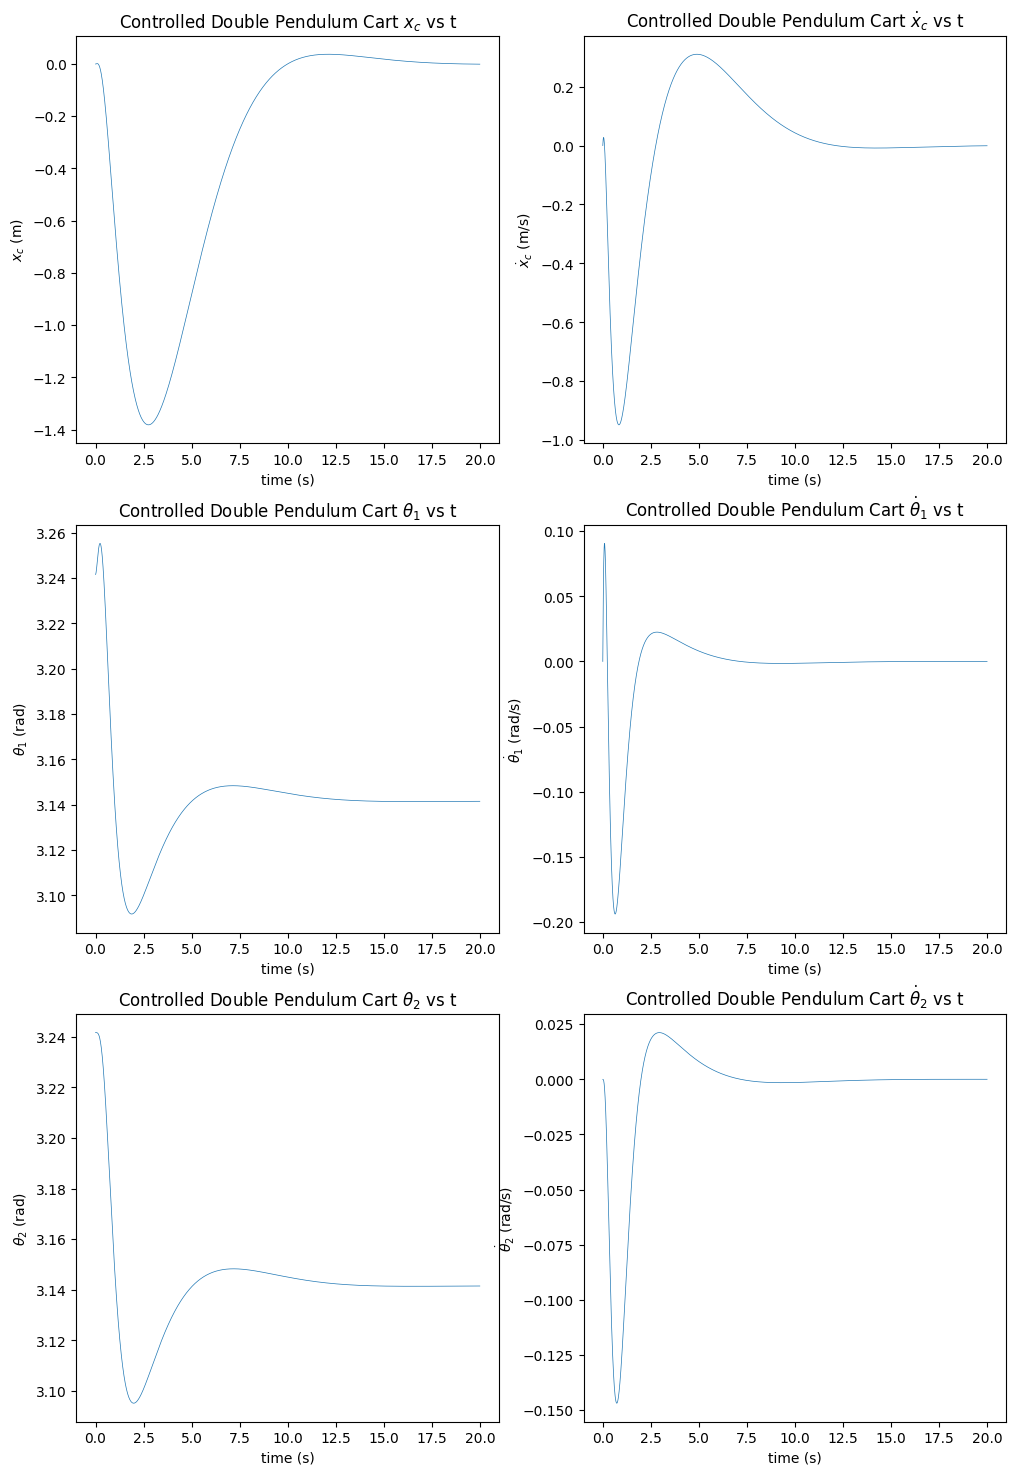

In [10]:
# Initialize Pendulum Configs class
n = 2
is_cart=True
params_controlled_double_0 = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg and all pendulum masses to 1kg and all lengths to 1m.

eps=.1
ICs_controlled_double_0 = np.array([0, np.pi+eps, np.pi+eps, 0, 0, 0]) # Sets the pendulum slightly above the horizontal axis. Vary eps to test the stability region.

sys_controlled_double_0 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_controlled_double_0, ICs=ICs_controlled_double_0) # Initializes the PendulumSystem class for the double pendulum with small angle initial conditions and default params

stabilized_state = np.array([0, np.pi, np.pi, 0, 0, 0]) # Upright at x=0, no initial velocities.
Q = np.diag([1, 10, 10, 1, 1, 1])
R = np.diag([.1])
LQR_controller = LQRController.design(system=sys_controlled_double_0, y_eq=stabilized_state, Q=Q, R=R)

sim_controlled_double_0 = sys_controlled_double_0.simulate(solver='DOP853', t_span=(0,20), dt=.01, controller=LQR_controller) # t_span = (0, 20) shows more of the control stabilization

ke_controlled_double_0, pe_controlled_double_0, energy_controlled_double_0 = sys_controlled_double_0.energy_history() # Calculates the energy of the system at each sim.t time step

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_controlled_double_0, n=n, is_cart=is_cart, title_prefix="Controlled Double Pendulum Cart")
plt.show()



The LQR control works very well and stabilizes quickly converging right to the exact equilibrium. The state space plots show the convergence ending at the equilibrium.

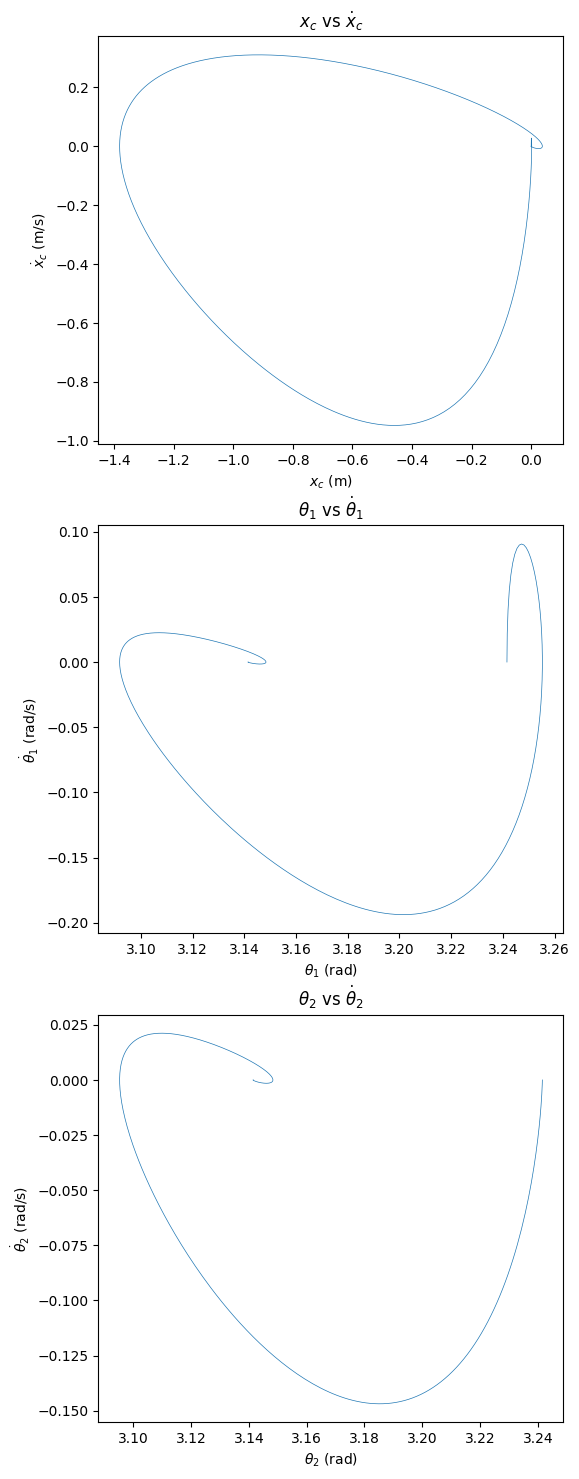

In [11]:
# Plot the statespace trajectories for each coordinate and its velocity
fig, axes = plt.subplots(3, 1, figsize=(6, 18))
axes[0].plot(sim_controlled_double_0.y[0], sim_controlled_double_0.y[3], linewidth=.5)
axes[1].plot(sim_controlled_double_0.y[1], sim_controlled_double_0.y[4], linewidth=.5)
axes[2].plot(sim_controlled_double_0.y[2], sim_controlled_double_0.y[5], linewidth=.5)
axes[0].set_xlabel(r'$x_c$ (m)')
axes[1].set_xlabel(r'$\theta_1$ (rad)')
axes[2].set_xlabel(r'$\theta_2$ (rad)')
axes[0].set_ylabel(r'$\dot{x}_c$ (m/s)')
axes[1].set_ylabel(r'$\dot{\theta}_1$ (rad/s)')
axes[2].set_ylabel(r'$\dot{\theta}_2$ (rad/s)')
axes[0].set_title(r'$x_c$ vs $\dot{x}_c$')
axes[1].set_title(r'$\theta_1$ vs $\dot{\theta}_1$')
axes[2].set_title(r'$\theta_2$ vs $\dot{\theta}_2$')
plt.show()

## Deadband LQR controlled double pendulum

Adding a deadband, now we should see oscillation around the desired stability point.

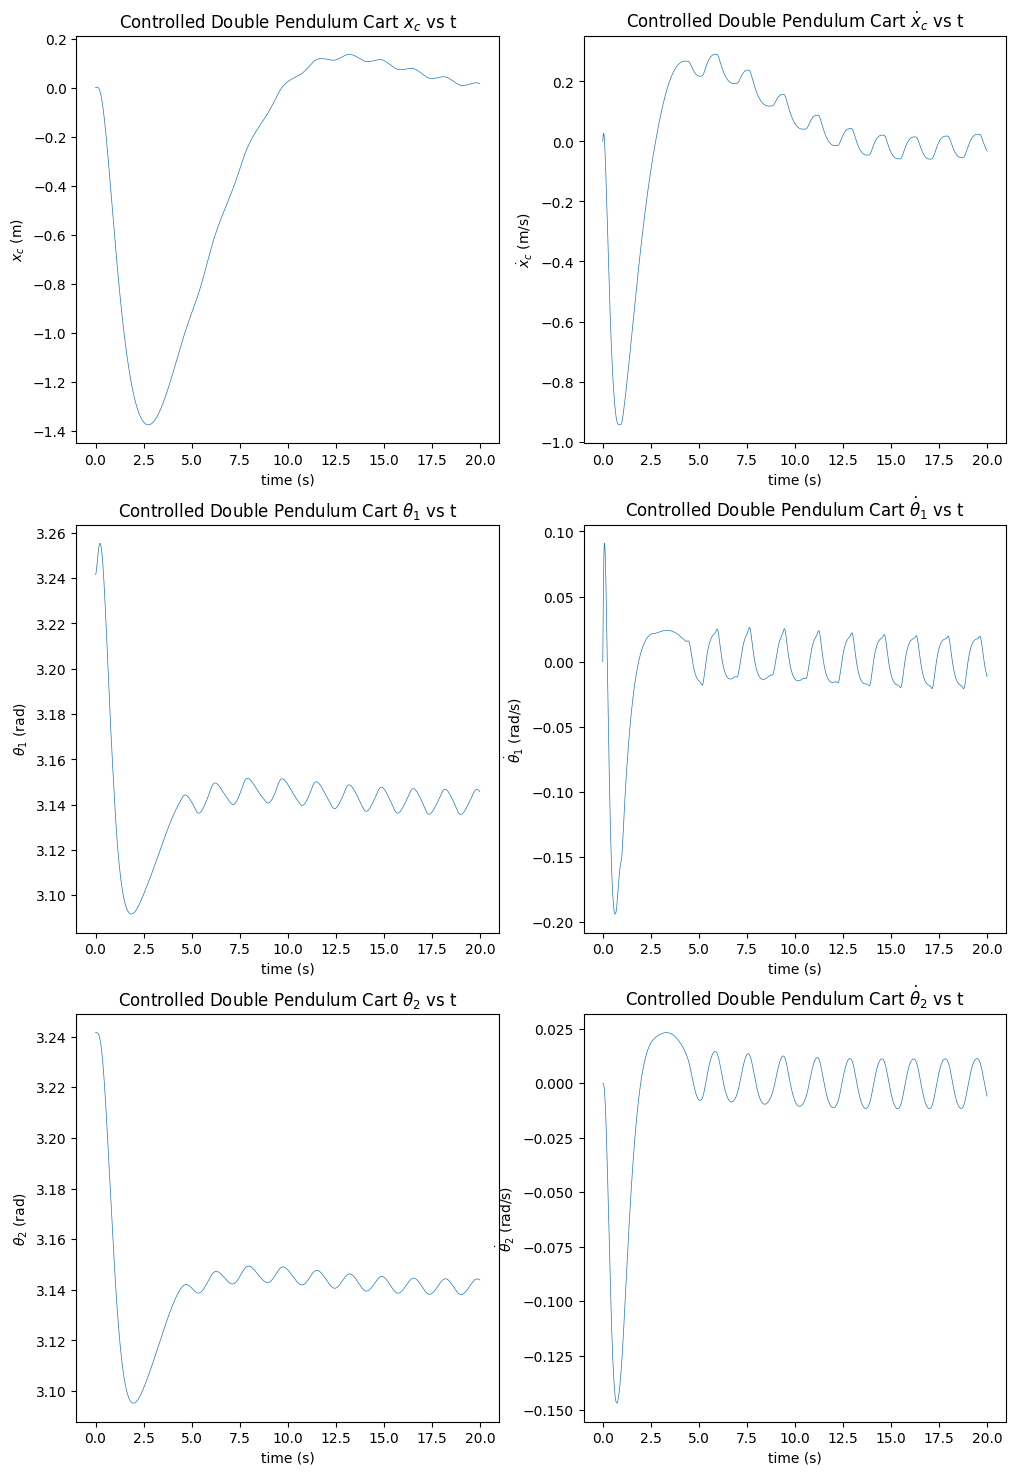

In [12]:
# Initialize Pendulum Configs class
n = 2
is_cart=True
params_controlled_double_1 = PendulumConfig.default_params(n=n, is_cart=is_cart) # Sets cart mass to 10kg and all pendulum masses to 1kg and all lengths to 1m.

eps=.1
ICs_controlled_double_1 = np.array([0, np.pi+eps, np.pi+eps, 0, 0, 0]) # Sets the pendulum slightly above the horizontal axis. Vary eps to test the stability region.

sys_controlled_double_1 = PendulumSystem(n=n, is_cart=is_cart, cfg=params_controlled_double_1, ICs=ICs_controlled_double_1) # Initializes the PendulumSystem class for the double pendulum with small angle initial conditions and default params

stabilized_state = np.array([0, np.pi, np.pi, 0, 0, 0]) # Upright at x=0, no initial velocities.
Q = np.diag([1, 10, 10, 1, 1, 1])
R = np.diag([.1])
Deadband_LQR_controller = DeadbandActuator(LQRController.design(system=sys_controlled_double_1, y_eq=stabilized_state, Q=Q, R=R), deadband_on=5, deadband_off=.5)

sim_controlled_double_1 = sys_controlled_double_1.simulate(solver='DOP853', t_span=(0,20), dt=.01, controller=Deadband_LQR_controller) # t_span = (0, 20) shows more of the control stabilization

# Plot coord vs time and velocity vs time
plot_pendulum_states(sim_controlled_double_1, n=n, is_cart=is_cart, title_prefix="Controlled Double Pendulum Cart")
plt.show()

With the deadband control, the double pendulum cart reaches a oscillating but controlled state within about 10 seconds worth of motion with a moderate $\approx 6^\circ$ offset from the vertical for each pendulum.

This should be the expected behavior for the triple pendulum cart system as well.

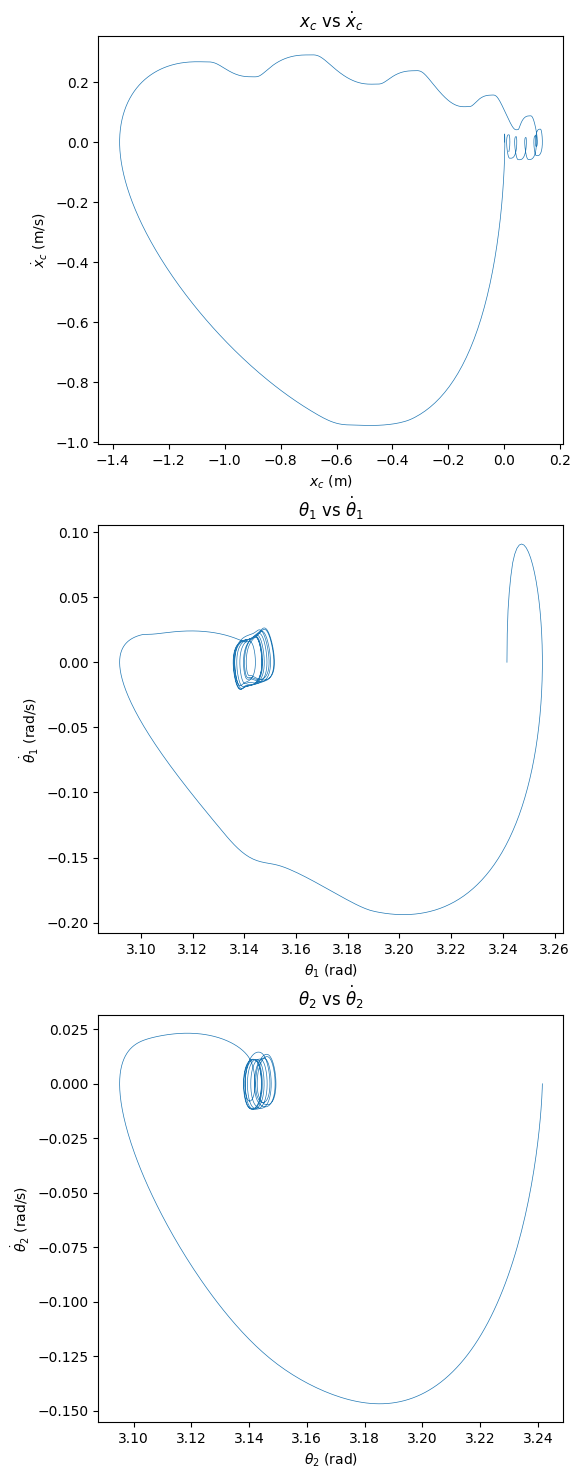

In [13]:
# Plot the statespace trajectories for each coordinate and its velocity
fig, axes = plt.subplots(3, 1, figsize=(6, 18))
axes[0].plot(sim_controlled_double_1.y[0], sim_controlled_double_1.y[3], linewidth=.5)
axes[1].plot(sim_controlled_double_1.y[1], sim_controlled_double_1.y[4], linewidth=.5)
axes[2].plot(sim_controlled_double_1.y[2], sim_controlled_double_1.y[5], linewidth=.5)
axes[0].set_xlabel(r'$x_c$ (m)')
axes[1].set_xlabel(r'$\theta_1$ (rad)')
axes[2].set_xlabel(r'$\theta_2$ (rad)')
axes[0].set_ylabel(r'$\dot{x}_c$ (m/s)')
axes[1].set_ylabel(r'$\dot{\theta}_1$ (rad/s)')
axes[2].set_ylabel(r'$\dot{\theta}_2$ (rad/s)')
axes[0].set_title(r'$x_c$ vs $\dot{x}_c$')
axes[1].set_title(r'$\theta_1$ vs $\dot{\theta}_1$')
axes[2].set_title(r'$\theta_2$ vs $\dot{\theta}_2$')
plt.show()

This is a useful visualization for the path the pendulum cart system takes on its way to stabability. One can see the oscillation around the staiblity point as the roughly circular paths it orbits around the upright $(0, \pi, \pi)$ position with all zero velocities,

## Conclusions

The double pendulum exhibits predictably chaotic behavior with lyapunov exponents providing the rate at which the trajectories diverge.

The LQR and Deadband with LQR control both stabilize the system around the desired fixed point well with the Deadband control oscillating close to the equilibrium.

Next, we move to the desired control system in a triple pendulum on a cart.

## Future Projects

Analyze where the double pendulum exhibits chaotic behavior in its initial conditions state space. This stems from similar work by 2swap in the video "Double Pendulums are Chaoticn't".

Create a heat map for the basin of stability for the fully upright case of controllability using monte carlo style simulations.